# Quantile Regression on the Four Chosen Series

This notebook builds a **LightGBM quantile regression** baseline for the same four representative series used in the EDA, classical, and deep notebooks:

- Longest History
- Highest Total Weight
- Most Volatile
- Most Stable

## What is evaluated

- Point accuracy from the **median forecast**: `RMSE`, `MAE`, `R2`, and weighted `Skill`
- Interval quality from the **10% to 90% interval**:
  - `PICP`: Prediction Interval Coverage Probability
  - `MPIW`: Mean Prediction Interval Width
  - `NMPIW`: Normalized MPIW
  - `Winkler`: interval sharpness plus under-coverage penalty

## Important data note

`test.parquet` does **not** contain `y_target`, so **PICP / MPIW cannot be scored on test**.  
To keep the results honest:

- model selection and interval scoring are done on a **chronological 80/20 split inside `train.parquet`**
- `test.parquet` is still audited in this notebook to show whether the exact chosen series continue there

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

ROOT = Path.cwd()
TRAIN_PATH = ROOT / "data" / "ts-forecasting" / "train.parquet"
TEST_PATH = ROOT / "data" / "ts-forecasting" / "test.parquet"
OUTPUT_DIR = ROOT / "Finial_notebooks" / "quantile_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES_KEYS = ["code", "sub_code", "sub_category", "horizon"]
TIME_COL = "ts_index"
TARGET_COL = "y_target"
WEIGHT_COL = "weight"
REASON_ORDER = [
    "Longest History",
    "Highest Total Weight",
    "Most Volatile",
    "Most Stable",
]
LAGS = 10
ROLLING_WINDOW = 5
SEED = 42
NOMINAL_COVERAGE = 0.80

FEATURE_COLS = [name for name in pq.ParquetFile(TRAIN_PATH).schema.names if name.startswith("feature_")]

print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Output directory: {OUTPUT_DIR}")

Feature columns: 86
Output directory: /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/Finial_notebooks/quantile_outputs


In [2]:
train_meta = pd.read_parquet(
    TRAIN_PATH,
    columns=[*SERIES_KEYS, TIME_COL, TARGET_COL, WEIGHT_COL],
)
test_meta = pd.read_parquet(
    TEST_PATH,
    columns=[*SERIES_KEYS, TIME_COL],
)

series_stats = (
    train_meta.groupby(SERIES_KEYS)
    .agg(
        length=(TIME_COL, "size"),
        start=(TIME_COL, "min"),
        end=(TIME_COL, "max"),
        total_weight=(WEIGHT_COL, "sum"),
        target_std=(TARGET_COL, "std"),
    )
    .reset_index()
)
series_stats["crosses_cutoff"] = (series_stats["start"] <= 2880) & (series_stats["end"] > 2880)

eligible = series_stats[(series_stats["crosses_cutoff"]) & (series_stats["length"] >= 120)].copy()
eligible["target_std"] = eligible["target_std"].fillna(0.0)
stable_pool = eligible[eligible["target_std"] > 0].copy()

chosen = pd.concat(
    [
        eligible.nlargest(1, "length").assign(reason="Longest History"),
        eligible.nlargest(1, "total_weight").assign(reason="Highest Total Weight"),
        eligible.nlargest(1, "target_std").assign(reason="Most Volatile"),
        stable_pool.nsmallest(1, "target_std").assign(reason="Most Stable"),
    ],
    ignore_index=True,
).drop_duplicates(subset=SERIES_KEYS)

chosen["reason"] = pd.Categorical(chosen["reason"], categories=REASON_ORDER, ordered=True)
chosen = chosen.sort_values("reason").reset_index(drop=True)
chosen["series_id"] = chosen.apply(
    lambda row: "__".join(
        [str(row["code"]), str(row["sub_code"]), str(row["sub_category"]), str(row["horizon"])]
    ),
    axis=1,
)

chosen_display = chosen[
    [*SERIES_KEYS, "series_id", "reason", "length", "start", "end", "target_std", "total_weight"]
].copy()
display(Markdown("## Chosen series"))
display(chosen_display.round({"target_std": 4, "total_weight": 4}))

## Chosen series

,code,sub_code,sub_category,horizon,series_id,reason,length,start,end,target_std,total_weight
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,X9BZ68VQ__OYJGNSQK__DPPUO5X2__1,Longest History,212,2826,3037,2.6416,9.060035e+02
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,SJZP0OVU__OYJGNSQK__NQ58FVQM__25,Highest Total Weight,156,2874,3032,0.0004,4.349747e+10
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,W4S29LF4__KL66VIS3__PHHHVYZI__25,Most Volatile,162,2747,2911,296.7600,4.563000e-01
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,SJZP0OVU__OYJGNSQK__NQ58FVQM__1,Most Stable,170,2874,3052,0.0001,3.869062e+10


In [3]:
exact_test_keys = test_meta[SERIES_KEYS].drop_duplicates()
signature_counts = (
    test_meta.groupby(["sub_category", "horizon"])
    .size()
    .reset_index(name="test_rows_same_subcategory_horizon")
)

test_audit = (
    chosen.merge(exact_test_keys.assign(exact_series_in_test=True), on=SERIES_KEYS, how="left")
    .merge(signature_counts, on=["sub_category", "horizon"], how="left")
    .loc[:, ["reason", "series_id", "exact_series_in_test", "test_rows_same_subcategory_horizon"]]
    .fillna({"exact_series_in_test": False, "test_rows_same_subcategory_horizon": 0})
)
test_audit["exact_series_in_test"] = test_audit["exact_series_in_test"].astype(bool)
test_audit["test_rows_same_subcategory_horizon"] = test_audit["test_rows_same_subcategory_horizon"].astype(int)

test_audit_path = OUTPUT_DIR / "quantile_test_audit.csv"
test_audit.to_csv(test_audit_path, index=False)

display(Markdown("## Test-set audit"))
display(test_audit)
print(
    "Exact chosen series present in test:",
    int(test_audit["exact_series_in_test"].sum()),
    "out of",
    len(test_audit),
)
print("Saved:", test_audit_path)

## Test-set audit

,reason,series_id,exact_series_in_test,test_rows_same_subcategory_horizon
0,Longest History,X9BZ68VQ__OYJGNSQK__DPPUO5X2__1,False,76292
1,Highest Total Weight,SJZP0OVU__OYJGNSQK__NQ58FVQM__25,False,65741
2,Most Volatile,W4S29LF4__KL66VIS3__PHHHVYZI__25,False,65741
3,Most Stable,SJZP0OVU__OYJGNSQK__NQ58FVQM__1,False,75887


Exact chosen series present in test: 0 out of 4
Saved: /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/Finial_notebooks/quantile_outputs/quantile_test_audit.csv


In [4]:
def build_exact_filter(frame: pd.DataFrame):
    expr = None
    for row in frame.itertuples(index=False):
        cond = (
            (ds.field("code") == row.code)
            & (ds.field("sub_code") == row.sub_code)
            & (ds.field("sub_category") == row.sub_category)
            & (ds.field("horizon") == row.horizon)
        )
        expr = cond if expr is None else expr | cond
    return expr


def read_exact_series(path: Path, include_target: bool = True, include_weight: bool = True) -> pd.DataFrame:
    cols = [*SERIES_KEYS, TIME_COL, *FEATURE_COLS]
    if include_target:
        cols.append(TARGET_COL)
    if include_weight:
        cols.append(WEIGHT_COL)

    dataset = ds.dataset(path, format="parquet")
    table = dataset.to_table(columns=cols, filter=build_exact_filter(chosen[SERIES_KEYS]))
    return table.to_pandas()


chosen_train = read_exact_series(TRAIN_PATH, include_target=True, include_weight=True)
chosen_train = chosen_train.sort_values(SERIES_KEYS + [TIME_COL]).reset_index(drop=True)

chosen_test = read_exact_series(TEST_PATH, include_target=False, include_weight=False)
chosen_test = chosen_test.sort_values(SERIES_KEYS + [TIME_COL]).reset_index(drop=True)

print("Chosen-train rows:", len(chosen_train))
print("Chosen-test rows :", len(chosen_test))

Chosen-train rows: 700
Chosen-test rows : 0


In [5]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))


def weighted_rmse_score(y_true, y_pred, weights) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)
    denom = np.sum(weights * y_true**2)
    if denom <= 0:
        return 0.0
    ratio = np.sum(weights * (y_true - y_pred) ** 2) / denom
    return float(np.sqrt(1.0 - _clip01(ratio)))


def point_metrics(y_true, y_pred, weights) -> dict[str, float]:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Skill": weighted_rmse_score(y_true, y_pred, weights),
    }


def _norm_weights(weights):
    if weights is None:
        return None
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= 0:
        return np.ones_like(weights) / len(weights)
    return weights / total


def picp(y_true, lower, upper, weights=None) -> float:
    inside = ((np.asarray(y_true) >= np.asarray(lower)) & (np.asarray(y_true) <= np.asarray(upper))).astype(float)
    return float(np.average(inside, weights=_norm_weights(weights)))


def mpiw(lower, upper, weights=None) -> float:
    width = np.asarray(upper, dtype=float) - np.asarray(lower, dtype=float)
    return float(np.average(width, weights=_norm_weights(weights)))


def nmpiw(y_true, lower, upper, weights=None) -> float:
    y_true = np.asarray(y_true, dtype=float)
    target_range = float(np.max(y_true) - np.min(y_true))
    return float(mpiw(lower, upper, weights) / (target_range + 1e-12))


def winkler_score(y_true, lower, upper, alpha: float, weights=None) -> float:
    y_true = np.asarray(y_true, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    score = (
        (upper - lower)
        + (2.0 / alpha) * np.maximum(lower - y_true, 0.0)
        + (2.0 / alpha) * np.maximum(y_true - upper, 0.0)
    )
    return float(np.average(score, weights=_norm_weights(weights)))


def normalize_training_weights(weights):
    weights = np.asarray(weights, dtype=float)
    positive = weights[weights > 0]
    if len(positive) == 0:
        return np.ones_like(weights)
    return weights / positive.mean()


def prepare_series_frame(series_df: pd.DataFrame, lags: int = LAGS, rolling_window: int = ROLLING_WINDOW):
    frame = series_df.sort_values(TIME_COL).reset_index(drop=True).copy()

    for lag in range(1, lags + 1):
        frame[f"lag_{lag}"] = frame[TARGET_COL].shift(lag)

    history = frame[TARGET_COL].shift(1)
    frame["roll_mean_5"] = history.rolling(rolling_window, min_periods=rolling_window).mean()
    frame["roll_std_5"] = history.rolling(rolling_window, min_periods=rolling_window).std()

    model_cols = [*FEATURE_COLS, *[f"lag_{lag}" for lag in range(1, lags + 1)], "roll_mean_5", "roll_std_5"]
    frame = frame.dropna(subset=[*[f"lag_{lag}" for lag in range(1, lags + 1)], "roll_mean_5", "roll_std_5"]).reset_index(drop=True)
    return frame, model_cols


def split_80_20(frame: pd.DataFrame):
    split = max(1, min(int(len(frame) * 0.8), len(frame) - 1))
    return frame.iloc[:split].copy(), frame.iloc[split:].copy()


def train_quantile_model(X, y, sample_weight, alpha: float):
    model = lgb.LGBMRegressor(
        objective="quantile",
        alpha=alpha,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        verbosity=-1,
    )
    model.fit(X, y, sample_weight=sample_weight)
    return model


def enforce_quantile_order(pred_low, pred_med, pred_high):
    ordered = np.sort(np.column_stack([pred_low, pred_med, pred_high]), axis=1)
    return ordered[:, 0], ordered[:, 1], ordered[:, 2]

In [6]:
results = []
prediction_rows = []
plot_payload = {}

for meta in chosen.itertuples(index=False):
    mask = np.ones(len(chosen_train), dtype=bool)
    for key in SERIES_KEYS:
        mask &= chosen_train[key].eq(getattr(meta, key))

    raw_series = chosen_train.loc[mask].copy()
    prepared, model_cols = prepare_series_frame(raw_series)
    train_case, val_case = split_80_20(prepared)

    X_train = train_case[model_cols]
    X_val = val_case[model_cols]
    y_train = train_case[TARGET_COL].to_numpy(dtype=float)
    y_val = val_case[TARGET_COL].to_numpy(dtype=float)
    w_train = train_case[WEIGHT_COL].to_numpy(dtype=float)
    w_val = val_case[WEIGHT_COL].to_numpy(dtype=float)

    model_weight = normalize_training_weights(w_train)
    model_low = train_quantile_model(X_train, y_train, model_weight, 0.10)
    model_med = train_quantile_model(X_train, y_train, model_weight, 0.50)
    model_high = train_quantile_model(X_train, y_train, model_weight, 0.90)

    pred_low_raw = model_low.predict(X_val)
    pred_med_raw = model_med.predict(X_val)
    pred_high_raw = model_high.predict(X_val)
    crossing_before_fix = float(np.mean((pred_low_raw > pred_med_raw) | (pred_med_raw > pred_high_raw)))

    pred_low, pred_med, pred_high = enforce_quantile_order(pred_low_raw, pred_med_raw, pred_high_raw)

    row = {
        "Series": meta.reason,
        "Series ID": meta.series_id,
        "Train len": int(len(train_case)),
        "Val len": int(len(val_case)),
        "Train ts start": int(train_case[TIME_COL].min()),
        "Train ts end": int(train_case[TIME_COL].max()),
        "Val ts start": int(val_case[TIME_COL].min()),
        "Val ts end": int(val_case[TIME_COL].max()),
        "Crossing rate before fix": crossing_before_fix,
        **point_metrics(y_val, pred_med, w_val),
        "wPICP_80": picp(y_val, pred_low, pred_high, w_val),
        "PICP_80": picp(y_val, pred_low, pred_high),
        "wMPIW_80": mpiw(pred_low, pred_high, w_val),
        "MPIW_80": mpiw(pred_low, pred_high),
        "wNMPIW_80": nmpiw(y_val, pred_low, pred_high, w_val),
        "NMPIW_80": nmpiw(y_val, pred_low, pred_high),
        "Winkler_80": winkler_score(y_val, pred_low, pred_high, alpha=0.20, weights=w_val),
        "Coverage gap vs 0.80": picp(y_val, pred_low, pred_high, w_val) - NOMINAL_COVERAGE,
    }
    results.append(row)

    pred_frame = val_case[[TIME_COL, TARGET_COL, WEIGHT_COL]].copy()
    pred_frame["Series"] = meta.reason
    pred_frame["Series ID"] = meta.series_id
    pred_frame["q10"] = pred_low
    pred_frame["q50"] = pred_med
    pred_frame["q90"] = pred_high
    prediction_rows.append(pred_frame)

    plot_payload[meta.reason] = {
        "train_y": y_train,
        "val_y": y_val,
        "pred_low": pred_low,
        "pred_med": pred_med,
        "pred_high": pred_high,
    }

metrics_df = pd.DataFrame(results)
metrics_df["Series"] = pd.Categorical(metrics_df["Series"], categories=REASON_ORDER, ordered=True)
metrics_df = metrics_df.sort_values("Series").reset_index(drop=True)

metrics_path = OUTPUT_DIR / "quantile_metrics_summary.csv"
predictions_path = OUTPUT_DIR / "quantile_validation_predictions.csv"

metrics_df.to_csv(metrics_path, index=False)
pd.concat(prediction_rows, ignore_index=True).to_csv(predictions_path, index=False)

display(Markdown("## Quantile metrics summary"))
display(
    metrics_df[
        [
            "Series",
            "RMSE",
            "MAE",
            "R2",
            "Skill",
            "wPICP_80",
            "wMPIW_80",
            "wNMPIW_80",
            "Winkler_80",
            "Coverage gap vs 0.80",
        ]
    ].round(4)
)

print("Saved:", metrics_path)
print("Saved:", predictions_path)

## Quantile metrics summary

,Series,RMSE,MAE,R2,Skill,wPICP_80,wMPIW_80,wNMPIW_80,Winkler_80,Coverage gap vs 0.80
0,Longest History,4.2489,1.8009,-0.0749,0.0000,0.7570,3.3713,0.1142,10.7768,-0.0430
1,Highest Total Weight,0.0005,0.0004,0.1097,0.5472,0.1666,0.0003,0.1818,0.0033,-0.6334
2,Most Volatile,65.5595,49.9673,0.7222,0.9623,0.7734,193.4258,0.4449,291.9718,-0.0266
3,Most Stable,0.0002,0.0001,-0.0544,0.1419,0.3745,0.0002,0.3215,0.0008,-0.4255


Saved: /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/Finial_notebooks/quantile_outputs/quantile_metrics_summary.csv
Saved: /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/Finial_notebooks/quantile_outputs/quantile_validation_predictions.csv


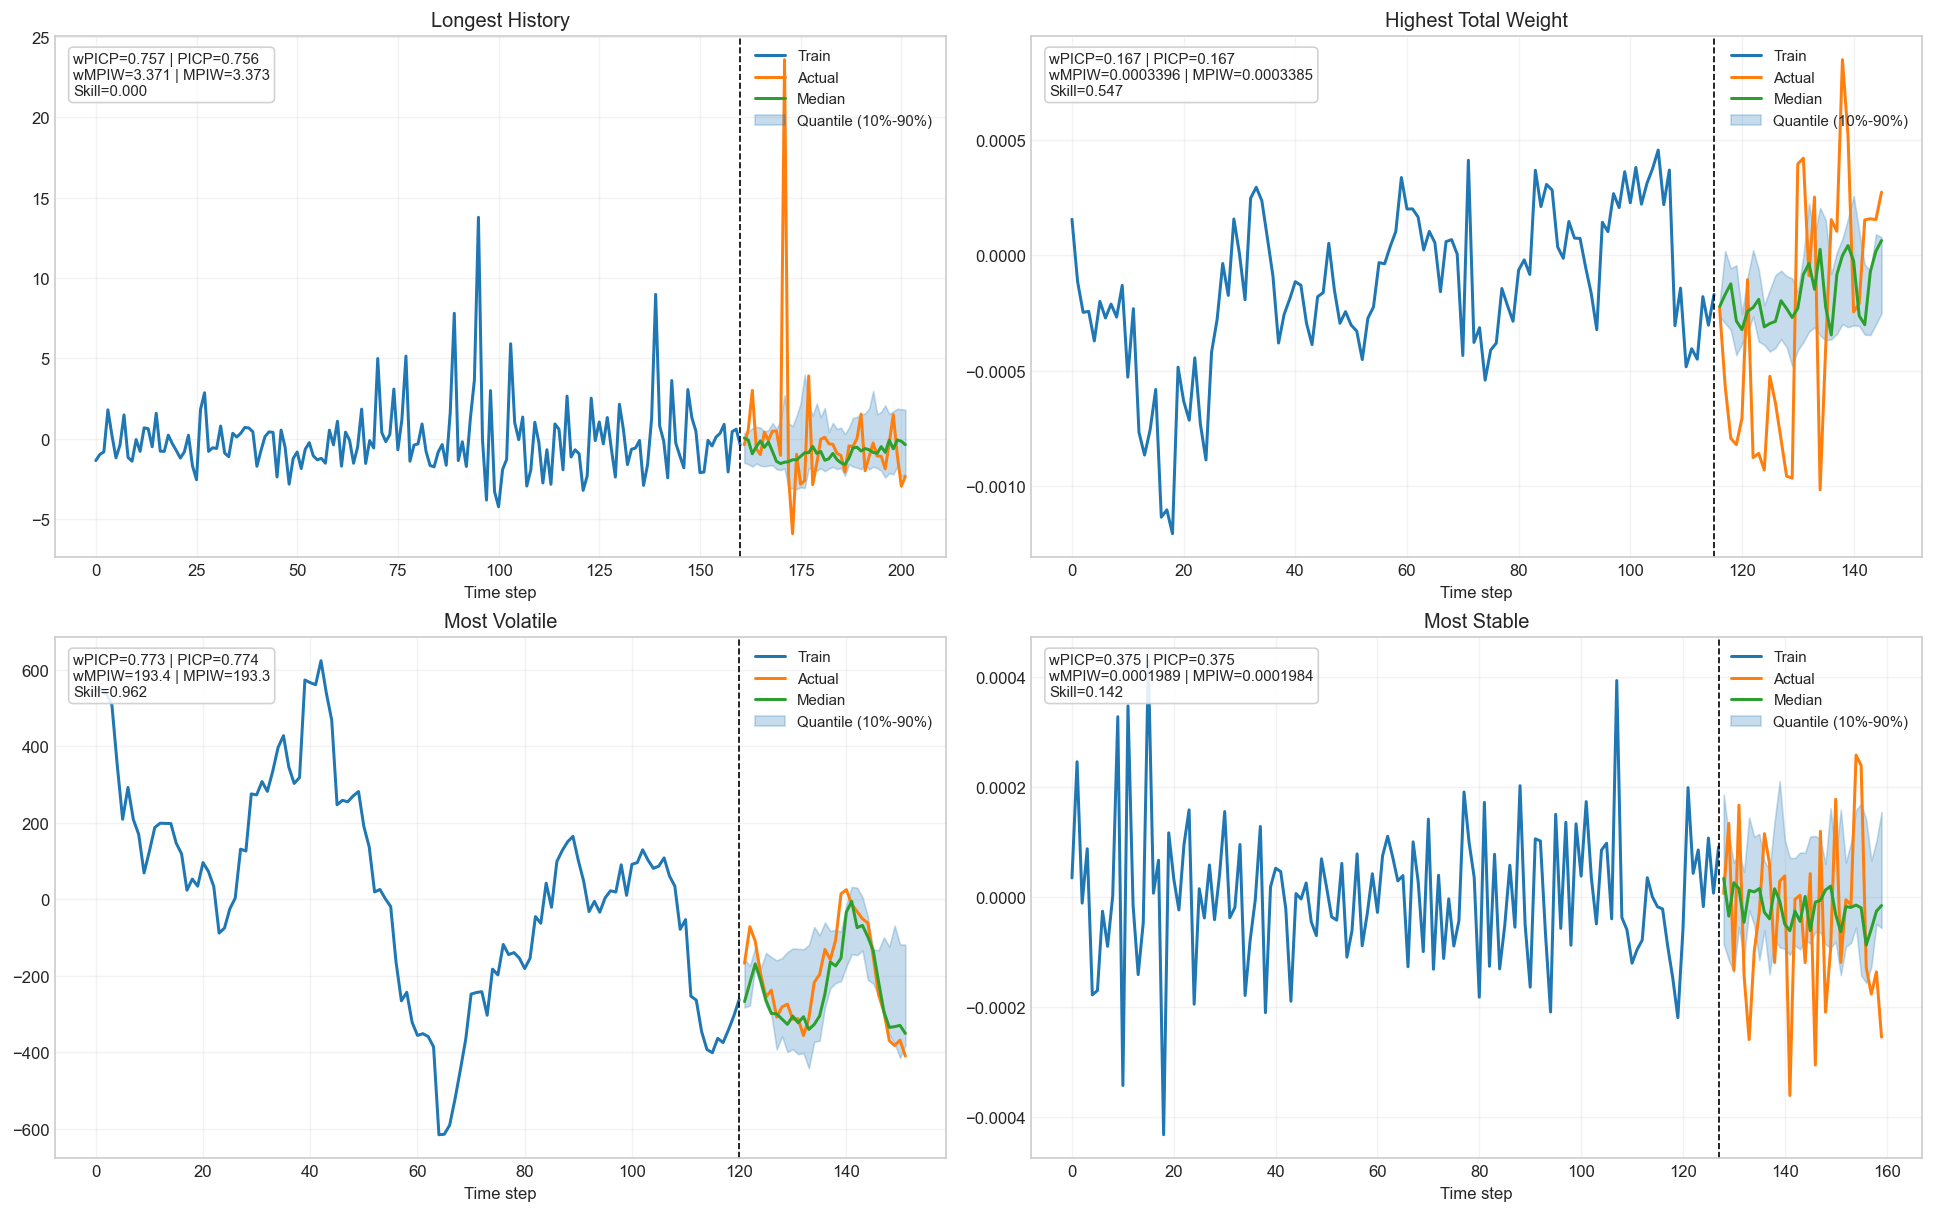

Saved: /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/Finial_notebooks/quantile_outputs/quantile_chosen_series_grid.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ax, reason in zip(axes, REASON_ORDER):
    payload = plot_payload[reason]
    row = metrics_df.loc[metrics_df["Series"] == reason].iloc[0]

    train_y = payload["train_y"]
    val_y = payload["val_y"]
    pred_low = payload["pred_low"]
    pred_med = payload["pred_med"]
    pred_high = payload["pred_high"]

    train_x = np.arange(len(train_y))
    val_x = np.arange(len(train_y), len(train_y) + len(val_y))

    ax.plot(train_x, train_y, label="Train", color="tab:blue", linewidth=1.8)
    ax.plot(val_x, val_y, label="Actual", color="tab:orange", linewidth=1.8)
    ax.plot(val_x, pred_med, label="Median", color="tab:green", linewidth=1.8)
    ax.fill_between(val_x, pred_low, pred_high, alpha=0.25, color="tab:blue", label="Quantile (10%-90%)")
    ax.axvline(len(train_y) - 1, color="black", linestyle="--", linewidth=1.0)

    ax.set_title(reason)
    stats_text = (
        f"wPICP={row['wPICP_80']:.3f} | PICP={row['PICP_80']:.3f}\n"
        f"wMPIW={row['wMPIW_80']:.4g} | MPIW={row['MPIW_80']:.4g}\n"
        f"Skill={row['Skill']:.3f}"
    )
    ax.text(
        0.02,
        0.97,
        stats_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#cccccc",
            "alpha": 0.88,
        },
    )
    ax.set_xlabel("Time step")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="upper right")

for ax in axes[len(REASON_ORDER):]:
    ax.axis("off")

plot_path = OUTPUT_DIR / "quantile_chosen_series_grid.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

In [8]:
interpretation = metrics_df[
    [
        "Series",
        "Skill",
        "wPICP_80",
        "wMPIW_80",
        "Coverage gap vs 0.80",
    ]
].copy()
interpretation["Interval read"] = np.where(
    interpretation["wPICP_80"] >= NOMINAL_COVERAGE,
    "coverage meets or exceeds target",
    "coverage is below target",
)

display(Markdown("## Quick read"))
display(interpretation.round(4))

display(
    Markdown(
        '''
        ### How to read PICP and MPIW here

        - `wPICP_80` should be read against the **0.80 nominal coverage** implied by the 10% to 90% interval.
        - `wMPIW_80` is the **weighted average interval width**. Lower is better only if coverage stays acceptable.
        - `Coverage gap vs 0.80` makes the trade-off explicit:
          - positive: conservative interval
          - near zero: well-calibrated interval
          - negative: under-covering interval
        - `Winkler_80` penalizes both **wide intervals** and **misses outside the interval**, so it is useful when PICP and MPIW disagree.
        '''
    )
)

## Quick read

,Series,Skill,wPICP_80,wMPIW_80,Coverage gap vs 0.80,Interval read
0,Longest History,0.0000,0.7570,3.3713,-0.0430,coverage is below target
1,Highest Total Weight,0.5472,0.1666,0.0003,-0.6334,coverage is below target
2,Most Volatile,0.9623,0.7734,193.4258,-0.0266,coverage is below target
3,Most Stable,0.1419,0.3745,0.0002,-0.4255,coverage is below target



        ### How to read PICP and MPIW here

        - `wPICP_80` should be read against the **0.80 nominal coverage** implied by the 10% to 90% interval.
        - `wMPIW_80` is the **weighted average interval width**. Lower is better only if coverage stays acceptable.
        - `Coverage gap vs 0.80` makes the trade-off explicit:
          - positive: conservative interval
          - near zero: well-calibrated interval
          - negative: under-covering interval
        - `Winkler_80` penalizes both **wide intervals** and **misses outside the interval**, so it is useful when PICP and MPIW disagree.
        